In [18]:
import pandas as pd

warehouse_slots = pd.read_csv(
    "../data/processed/warehouse_slots.csv"
)

product_base = pd.read_csv(
    "../data/processed/final_slot_recommendations.csv"
)

orders = pd.read_csv(
    "../data/processed/cleaned_online_retail.csv"
)


C:\Users\HP\AppData\Local\Temp\ipykernel_18140\4196475847.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv(


In [19]:
print(warehouse_slots.columns.tolist())
print(product_base.columns.tolist())
print(orders.columns.tolist())

['slot', 'x', 'y']
['StockCode', 'order_frequency', 'total_quantity', 'avg_quantity_per_order', 'related_product_count', 'cluster_name', 'recommended_zone', 'distance_from_packing', 'picking_priority', 'current_distance', 'distance_saved']
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [20]:
product_base = product_base.reset_index(drop=True)

product_base["current_slot"] = [
    warehouse_slots.iloc[i % len(warehouse_slots)]["slot"]
    for i in range(len(product_base))
]

In [21]:
slot_coordinates = warehouse_slots.set_index("slot")[
    ["x", "y"]
].to_dict("index")

product_base["current_x"] = product_base["current_slot"].map(
    lambda x: slot_coordinates[x]["x"]
)

product_base["current_y"] = product_base["current_slot"].map(
    lambda x: slot_coordinates[x]["y"]
)

In [22]:
print(
    product_base[
        ["StockCode", "current_slot", "current_x", "current_y"]
    ].head(10)
)

  StockCode current_slot  current_x  current_y
0    85099B           A1          0          0
1    85123A           A2          0          1
2     22197           A3          0          2
3     84879           A4          0          3
4     21212           A5          0          4
5     47566           B1          1          0
6     23084           B2          1          1
7     20725           B3          1          2
8     84077           B4          1          3
9     22423           B5          1          4


In [23]:
orders = orders[
    ["InvoiceNo", "StockCode"]
].drop_duplicates()

orders_with_locations = orders.merge(
    product_base[
        ["StockCode", "current_slot", "current_x", "current_y"]
    ],
    on="StockCode",
    how="left"
)

In [24]:
print(
    orders_with_locations[
        ["current_x", "current_y"]
    ].isna().sum()
)

current_x    0
current_y    0
dtype: int64


In [25]:
packing_x = 0
packing_y = 0

In [26]:
orders_with_locations["distance_from_packing"] = (
    abs(orders_with_locations["current_x"] - packing_x)
    +
    abs(orders_with_locations["current_y"] - packing_y)
)

In [27]:
order_distance = orders_with_locations.groupby(
    "InvoiceNo"
)["distance_from_packing"].sum().reset_index()

order_distance = order_distance.rename(
    columns={
        "distance_from_packing": "total_picking_distance"
    }
)

In [28]:
print(order_distance.head())

  InvoiceNo  total_picking_distance
0    536365                      23
1    536366                       9
2    536367                      48
3    536368                      17
4    536369                       2


In [29]:
average_distance = order_distance[
    "total_picking_distance"
].mean()

print(
    f"Average current picking distance: {average_distance:.2f}"
)

Average current picking distance: 102.94


In [30]:
print(
    "Minimum distance:",
    order_distance["total_picking_distance"].min()
)

print(
    "Maximum distance:",
    order_distance["total_picking_distance"].max()
)

print(
    "Average distance:",
    order_distance["total_picking_distance"].mean()
)

Minimum distance: 0
Maximum distance: 4428
Average distance: 102.94359282637011


In [31]:
print(
    "Median distance:",
    order_distance["total_picking_distance"].median()
)

Median distance: 60.0


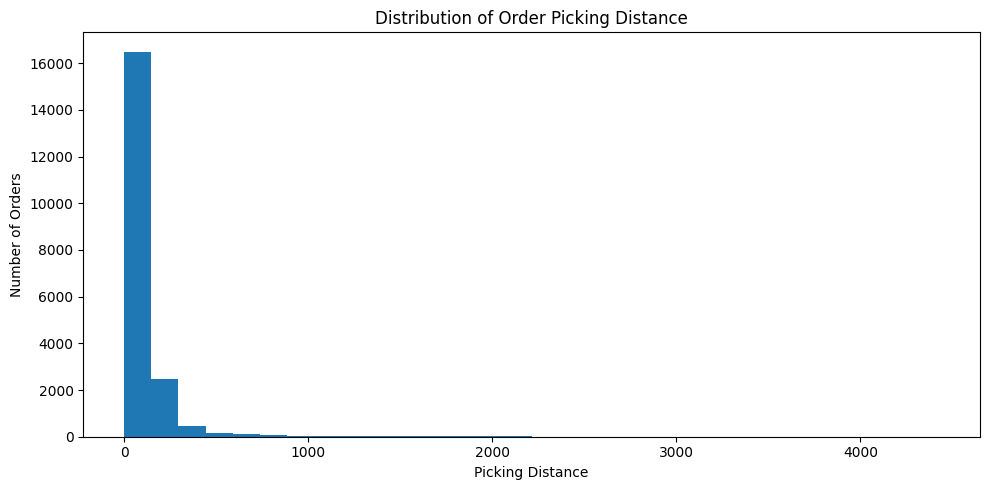

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    order_distance["total_picking_distance"],
    bins=30
)

plt.title("Distribution of Order Picking Distance")
plt.xlabel("Picking Distance")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [33]:
order_distance.to_csv(
    "../data/processed/current_order_distances.csv",
    index=False
)

In [34]:
orders_with_locations.to_csv(
    "../data/processed/order_product_locations.csv",
    index=False
)